

# Data Analysis




<h3>What are the main characteristics that have the most impact on the car price?</h3>


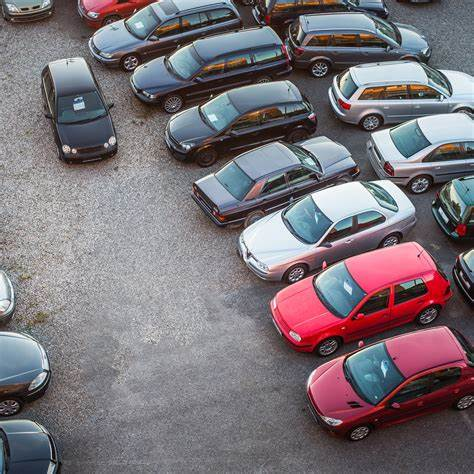

## Import Data from Module 2


<h4>Setup</h4>


In [1]:
# data visualization 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 
# data prossiceng
import pandas as pd 
import numpy as np

In [2]:
file_name="usedcars.csv"

In [3]:
df = pd.read_csv(file_name)
df.sample(6)

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
198,-1,95,volvo,std,four,sedan,rwd,front,109.1,0.907256,...,8.8,134.0,5500.0,18,23,21485.0,13.055556,Medium,0,1
16,0,122,bmw,std,four,sedan,rwd,front,110.0,0.946660,...,8.0,182.0,5400.0,15,20,36880.0,15.666667,High,0,1
60,0,122,mazda,std,four,sedan,fwd,front,98.8,0.854397,...,22.7,64.0,4650.0,36,42,10795.0,6.527778,Low,1,0
50,1,113,mazda,std,four,sedan,fwd,front,93.1,0.801538,...,9.0,68.0,5000.0,31,38,6695.0,7.580645,Low,0,1
133,2,104,saab,turbo,four,sedan,fwd,front,99.1,0.896684,...,9.0,160.0,5500.0,19,26,18620.0,12.368421,High,0,1
146,1,87,toyota,std,two,hatchback,fwd,front,95.7,0.762614,...,9.0,62.0,4800.0,35,39,5348.0,6.714286,Low,0,1


<h4>How to choose the right visualization method?</h4>
<p>When visualizing individual variables, it is important to first understand what type of variable you are dealing with. This will help us find the right visualization method for that variable.</p>


In [ ]:
# list the data types for each column
print(df.dtypes)

In [ ]:
# cheack for nulls
df.info()

## DATA CLEAN

In [4]:
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

## the distrepution of data

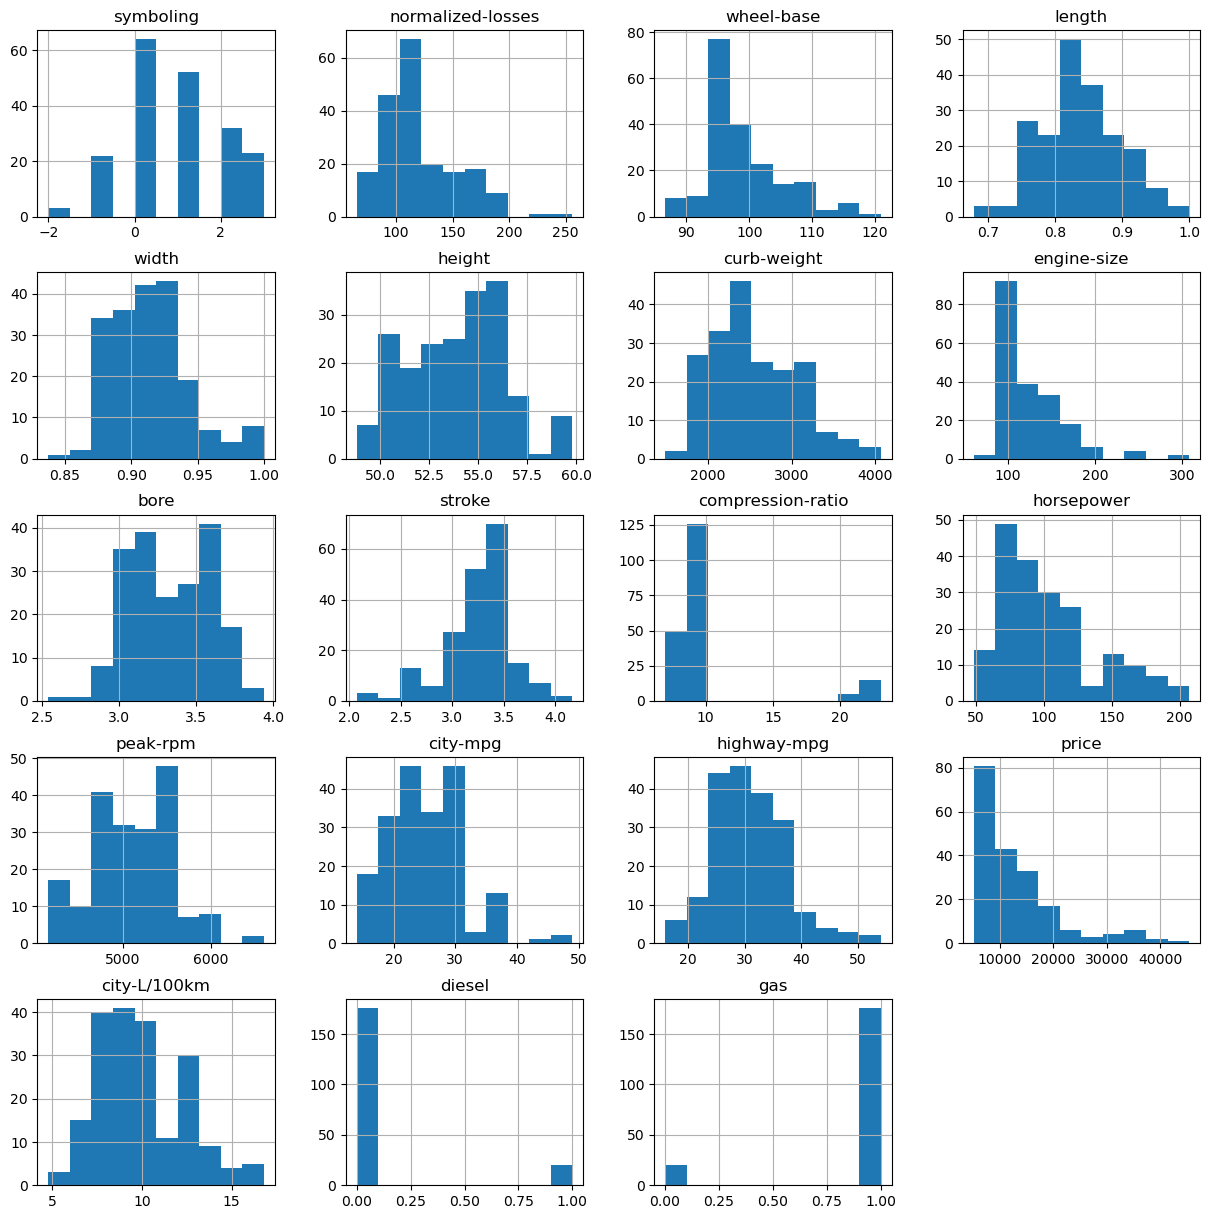

In [5]:
# the distrepution of data
df.hist(figsize=(15,15))
plt.show()

<h2>Continuous Numerical Variables:</h2> 



In [ ]:
# Engine size as potential predictor variable of price
sns.regplot(x="engine-size", y="price", data=df)
plt.ylim(0,)

In [ ]:
df[["engine-size", "price"]].corr()

Highway mpg is a potential predictor variable of price. Let's find the scatterplot of "highway-mpg" and "price".


In [ ]:
sns.regplot(x="highway-mpg", y="price", data=df)

In [ ]:
df[['highway-mpg', 'price']].corr()

<h3>Weak Linear Relationship</h3>


Let's see if "peak-rpm" is a predictor variable of "price".


In [ ]:
sns.regplot(x="peak-rpm", y="price", data=df)

In [ ]:
df[['peak-rpm','price']].corr()

In [ ]:
# Write your code below and press Shift+Enter to execute 
sns.regplot(x="stroke", y="price", data=df)

<h3>Categorical Variables</h3>

<p>These are variables that describe a 'characteristic' of a data unit, and are selected from a small group of categories. The categorical variables can have the type "object" or "int64". A good way to visualize categorical variables is by using boxplots.</p>


In [ ]:
df.head()

Let's look at the relationship between "body-style" and "price".


In [ ]:
sns.boxplot(x="body-style", y="price", data=df)

In [ ]:
sns.boxplot(x="engine-location", y="price", data=df)


<p>Here we see that the distribution of price between these two engine-location categories, front and rear, are distinct enough to take engine-location as a potential good predictor of price.</p>


In [ ]:
# drive-wheels
sns.boxplot(x="drive-wheels", y="price", data=df)

<p>Here we see that the distribution of price between the different drive-wheels categories differs. As such, drive-wheels could potentially be a predictor of price.</p>


## Descriptive Statistical Analysis


<p>Let's first take a look at the variables by utilizing a description method.</p>

<p>The <b>describe</b> function automatically computes basic statistics for all continuous variables. Any NaN values are automatically skipped in these statistics.</p>

This will show:
<ul>
    <li>the count of that variable</li>
    <li>the mean</li>
    <li>the standard deviation (std)</li> 
    <li>the minimum value</li>
    <li>the IQR (Interquartile Range: 25%, 50% and 75%)</li>
    <li>the maximum value</li>
<ul>


 We can apply the method "describe" as follows:


In [ ]:
df.describe()

In [ ]:
#categorical
df.describe(include=['object'])

In [ ]:
correlation=df.corr(numeric_only=True)
sns.heatmap(correlation)

<h3>Value Counts</h3>


In [ ]:
df['drive-wheels'].value_counts()


In [ ]:
df_gro1=df[['body-style','price']]
df_grouped1=df_gro1.groupby(['body-style'],as_index=False).mean()
df_grouped1

In [ ]:
# engine-location as variable
engine_loc_counts = df['engine-location'].value_counts()
engine_loc_counts.head(10)

In [ ]:
df_gro2=df[['engine-location','price']]
df_grouped2=df_gro2.groupby(['engine-location'],as_index=False).mean()
df_grouped2

                       bore    stroke  compression-ratio  horsepower
bore               1.000000 -0.049606          -0.000044    0.579114
stroke            -0.049606  1.000000           0.191776    0.139409
compression-ratio -0.000044  0.191776           1.000000   -0.232284
horsepower         0.579114  0.139409          -0.232284    1.000000


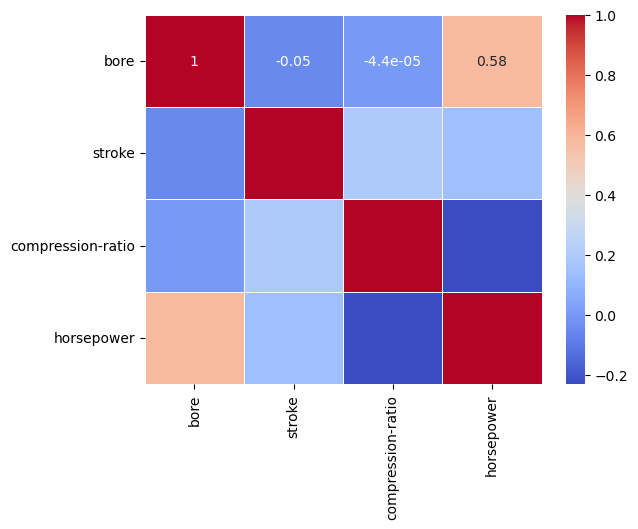

In [6]:
# Write your code below and press Shift+Enter to execute 
s=df[['bore','stroke','compression-ratio','horsepower']].corr()
print(s)
sns.heatmap(s,annot=True,cmap='coolwarm',linewidths=.5)
plt.show()

## Conclusion

Continuous numerical variables:
<ul>
    <li>Engine-size</li>
    <li>Horsepower</li>
    <li>City-mpg</li>
    <li>Highway-mpg</li>
    <li>Wheel-base</li>
    <li>Bore</li>
</ul>
    
Categorical variables:
<ul>
    <li>Drive-wheels</li>
    <li>engine_location</li>
</ul>

<p>As we now move into building machine learning models to automate our analysis, feeding the model with variables that meaningfully affect our target variable will improve our model's prediction performance.</p>


## liner regression

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

In [ ]:
df.columns

In [8]:


# Correct the column names if necessary
x = df[['engine-size', 'horsepower', 'city-mpg', 'highway-mpg', 'wheel-base', 'bore']]
y = df[['price']]


In [9]:
# Split the data into training and testing datasets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2 , random_state=42)

In [10]:
# Create a linear regression model
model=LinearRegression()
# Fit the model to the training data
model.fit(x_train, y_train)

LinearRegression()

In [11]:
#Make predictions on the testing data
y_pred = model.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 17920717.54962782


In [12]:
print(len(x_test))
print(len(y_test))


40
40


In [13]:
model.score(x_test,y_test)

0.782477186542988

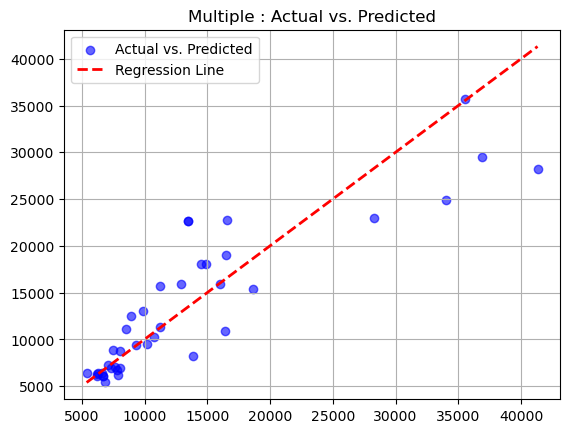

In [14]:
# Create a scatter plot
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, label='Actual vs. Predicted')

# Add a regression line (y = x)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2, label='Regression Line')

plt.title('Multiple : Actual vs. Predicted')
plt.legend()
plt.grid(True)
plt.show()